# Exercise 1 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Rubie Luo

Sciper number: 423142

#### Group Member 2:
Name: Kristina Nordang

Sciper number: 423319

#### Group Member 3:
Name: Oussama Yazidi

Sciper number: 311 471

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [36]:
%pip install matplotlib torch scipy numpy

Note: you may need to restart the kernel to use updated packages.


In [37]:
import os
from typing import List

import numpy as np

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import sys

sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from plot import plot_log_lines, plot_lines
# %load_ext autoreload
# %autoreload 2

# Dynamic Programming exercise

We will make use of the operators introduced in the slides of lectures 1 and 2. 
$(T V)(s)$, $\mathcal{G}$ and $T^{\pi}$

Before diving into the implementation of Value Iteration or Policy Iteration, we instantiate an environment using the library in the folder `src`.

The gridworld environment is instantiated via the class `GridWorldEnvironment`. It takes 4 input values:

- `reward_mode` : integer between 0 and 3 for different reward profiles
- `size`: Gridworld size
- `prop`: probability assigned to the event that the agent does not follow the chosen action but another one selected uniformly at random.
- `gamma`: the discount factor of the environment.

In [38]:
reward_mode = 2 # put an image to show which is the reward
size = 10 
prop = 0
gamma=0.99 # rename discount_factor
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)

Below, we illustrate how to access the gridworld environment, i.e. how to access the reward, the transition matrix and the discount factor.

In [39]:
size = 3
gridworld_example = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)


***Interface with a Gridworld instance***
- `print(gridworld.n_states)` #return the number of states
- `print(gridworld.n_actions)` #return the number of actions
- `print(gridworld.r)` #return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` #Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.



<img src="src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

Then we set up the solver object that will implement the routine needed to evaluate the value of the produced policies

In [40]:
solver = MDPsolver(gridworld)

We will use this solver to compute the optimal value function to measure the suboptimality of the policies produced by value iteration or policy iteration.

To access the optimal value function use `solver.v`.

In [41]:
solver.value_iteration()

## Ex 1: Value Iteration [20 pts.]

### 1.1 Implement value iteration

In [42]:
def value_iteration(env, tol=1e-10):
    """Implementation of value iteration, note that the implementation is based on value iteration mentioned in the lecture.
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm converges
    Returns:
        policies: policy  at each iteration (list)
        vs: value functions at each iteration (list)
    """
    policies = []
    vs = []
    v = np.zeros(env.n_states) # initialize value function
    q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
    
    while True:
        v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v) # ??? # calculate Q-value
        v = np.max(q, axis=1) # ??? # update value function
        policies.append(np.argmax(q, axis=1)) # ??? # obtain policy
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol: # convergence criterion
            break
    return policies, vs

In [43]:
policies, vs = value_iteration(gridworld)

### 1.2: Evaluate the extracted policies

For the evaluation of the sequence of policies, i.e. computing $V^\pi$ for each policy $\pi$ we recall that $V^\pi$ is the fixed point $V^\pi = T^\pi (V^\pi)$.
In the following code, we ask you to apply the operator $T^\pi$ a number of time sufficient to find a value $V$ such that $ || T^\pi(V) - V || \leq \mathrm{tol}$

In [44]:
def evaluate_policy_sequence(policies, env, tol=1e-10):
    """Inplementation of policy evaluation through iteratively applying policy value iteration 
    Args:
        policies: a list of policies obtained by section 1.1
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        values: a list of value function for each policy
    """
    values = []
    for pi in policies:
        v = np.zeros(env.n_states) # initialize value function
        q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
        while True:
            v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
            for a in range(env.n_actions):
                q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v) # ??? #calculate Q-value
            for s in range(env.n_states):
                action_taken = pi[s] # obtain the action determined by the policy
                v[s] = q[s,action_taken] # ??? #calculate value function by $v(s) = Q(s,pi(s))$
            if np.linalg.norm(v - v_old) < tol: # convergence criterion
                break
        values.append(v)
    return values

In [45]:
values = evaluate_policy_sequence(policies, gridworld)

### 1.3: Plot the results 

Plot using the method ```plot_lines(list_to_plot, list_name, axis_label, folder, title, x_axis = None, show = False) ```

Compute both the iterates $V_t$ produced by value iteration and the value function achieved by the extracted policies $V^{\pi_t}$ with $\pi_t = \mathcal{G}(V_t)$. What do you observe ?


$V^{\pi_t}$ seems to converge much more quickly than $V_t$. $V_t$ improves significantly after the first iteration, shown by its large jump to a less negative suboptimality, but than takes ~17.5 iterations until its subopt is close to 0. $V^{\pi_t}$ on the other hand has multiple larger steps, and gets close to 0 in around 8 iterations, less than half the number of iterations as $V_t$. Also, it can be observed that the subopt of $V_t$ is negative and increases (closer to 0), while $V^{\pi_t}$ is positive and decreases (closer to 0).

In [46]:
def compute_subopt(values, v_star):
    """
    Args:
        values: a list of value function.
        v_star: the optimal value function obtained by MDP.solver
    Returns:
        subopts: an array indicates the suboptimality.
    """
    subopts = []
    for v in values:
        i = np.argmax(np.abs(v - v_star))
        subopts.append(-v[i] + v_star[i])
    return np.array(subopts)

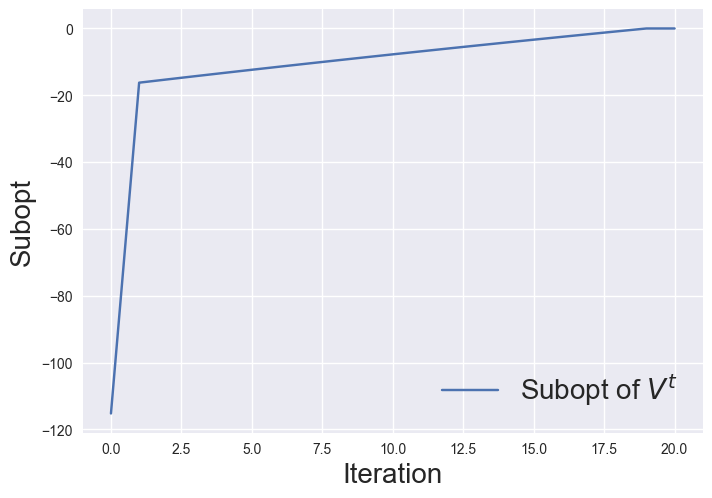

In [47]:
plot_lines([compute_subopt(vs, solver.v)], [r"Subopt of $V^t$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

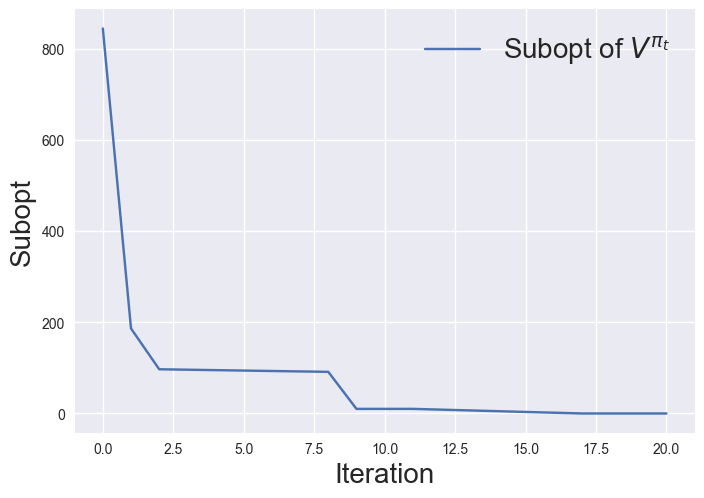

In [48]:
plot_lines([compute_subopt(values, solver.v)], [r"Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

To better appreciate the difference in the convergence plot use log scale.

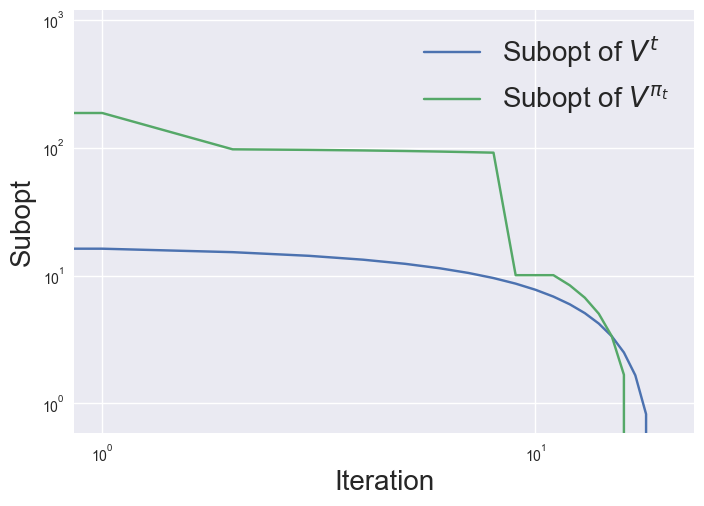

In [49]:
plot_log_lines([-compute_subopt(vs, solver.v), compute_subopt(values, solver.v)], 
               [r"Subopt of $V^t$", r"Subopt of $V^{\pi_t}$"], 
               ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

**Question** : 
- Prove that $T$ is a contraction, that is $|| T(V) - T(V') ||_{\infty} \leq \gamma || V - V' ||_{\infty}$.
- Why the iterates of Value Iterations are an upper bound to $V^\star$ ? How is this possible considering that $V^\star \triangleq \max_{\pi \in \Pi} V^{\pi}$ ?

**Answers**

**Proof.**

For any $V', V \in \mathbb{R}^{|\mathcal{S}|}$ and $s \in \mathcal{S}$:

$$\big|(\mathcal{T}V')(s) - (\mathcal{T}V)(s)\big|$$

$$= \left|\max_{a \in \mathcal{A}} \left[r(s,a) + \gamma \sum_{s' \in \mathcal{S}} P(s'|s,a)V'(s')\right] - \max_{a' \in \mathcal{A}} \left[r(s,a') + \gamma \sum_{s' \in \mathcal{S}} P(s'|s,a')V(s')\right]\right|$$

**Step 1:** $|\max_a f(a) - \max_a g(a)| \leq \max_a |f(a) - g(a)|$:

$$\leq \max_{a \in \mathcal{A}} \left|\left(r(s,a) + \gamma \sum_{s' \in \mathcal{S}} P(s'|s,a)V'(s')\right) - \left(r(s,a) + \gamma \sum_{s' \in \mathcal{S}} P(s'|s,a)V(s')\right)\right|$$

$$= \max_{a \in \mathcal{A}}\ \gamma \sum_{s' \in \mathcal{S}} P(s'|s,a)\big|V'(s') - V(s')\big|$$

**Step 2:** replace $|V'(s') - V(s')|$ by its upper bound $\|V' - V\|_\infty$:

$$\leq \max_{a \in \mathcal{A}}\ \gamma \sum_{s' \in \mathcal{S}} P(s'|s,a) \cdot \|V' - V\|_\infty$$

**Step 3:**  $\sum_{s'} P(s'|s,a) = 1$:

$$= \|V' - V\|_\infty \cdot \max_{a \in \mathcal{A}}\ \gamma \underbrace{\sum_{s' \in \mathcal{S}} P(s'|s,a)}_{=1} = \gamma\|V' - V\|_\infty $$

$$ \implies || T(V) - T(V') ||_{\infty} \leq \gamma || V - V' ||_{\infty} \blacksquare$$

**Answer**
 
Since Value Iteration is initialized with $V_0 = \mathbf{0}$, and all components of $V^\star$ are negative in this environment (as confirmed with `solve.v`), we immediately have $V_0 \geq V^\star$ component-wise. This initial ordering, combined with two key properties of the Bellman optimality operator $\mathcal{T}$, is sufficient to establish that every iterate remains an upper bound of $V^\star$.

Recall that $V^\star$ is the unique fixed point of $\mathcal{T}$, i.e. $\mathcal{T}V^\star = V^\star$, and that $\mathcal{T}$ is monotone: $V \geq V' \implies \mathcal{T}V \geq \mathcal{T}V'$. Applying $\mathcal{T}$ to both sides of $V_0 \geq V^\star$ and using the fixed point property:

$$V_0 \geq V^\star \implies \mathcal{T}V_0 \geq \mathcal{T}V^\star = V^\star \implies V_1 \geq V^\star$$

The same argument applies inductively at every iteration, yielding $V_k \geq V^\star$ for all $k \geq 0$. Therefore, in this setting, every iterate of Value Iteration is a component-wise upper bound of $V^\star$, and the algorithm converges to $V^\star$ monotonically from above.


# Ex 2: Policy Iteration [20 pts.]

In [50]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v) # ???
        for s in range(env.n_states):
            v[s] = q[s, pi[s]] # ???
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

In [51]:
def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = []
    for s in range(q.shape[0]):
        policy.append(np.argmax(q[s, :])) # ???
    return policy

In [52]:
def policy_iteration(env, tol=1e-20):
    """Implementation of policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        v, q = evaluate_policy(pi,env,tol) # ???
        pi = get_greedy_policy(q) # ???
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs , pi 

In [53]:
values_pi , _ =policy_iteration(gridworld)

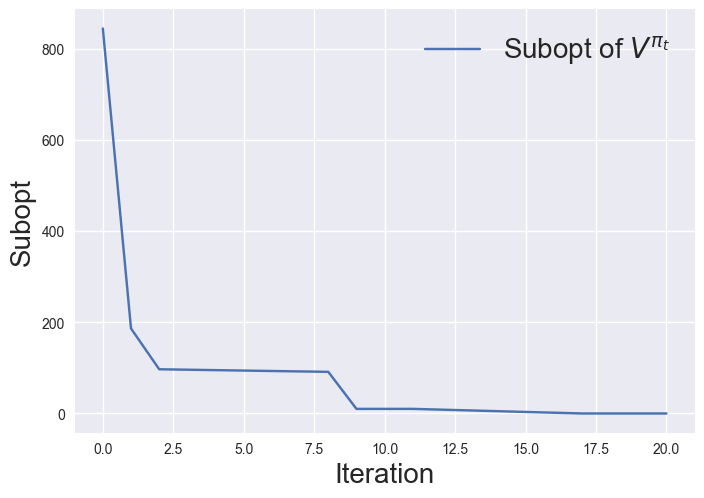

In [54]:
plot_lines([compute_subopt(values, solver.v)], [r"Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

### Compare with Value Iteration

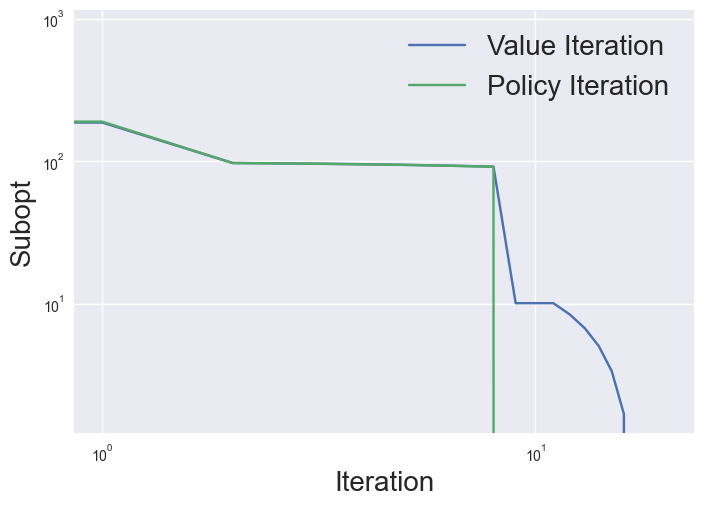

In [55]:
plot_log_lines([compute_subopt(values, solver.v), compute_subopt(values_pi, solver.v)], 
               ["Value Iteration", "Policy Iteration"], 
               ["Iteration", "Subopt"], "figs", "VIvsPI.pdf", show = True)

***Questions :*** 
- Which algorithm converges faster ?
- Is it theoretically expected ? Answer listing the expected number of iterations needed for VI and PI to converge ?


***Answers***

Policy iteration converges faster. This makes sense because policy iteration alternates between policy evaluation and policy improvements, thus evaluates the value function for a policy and takes a "greedy" jump to a better policy. Value iteration repeatedly applies the Bellman Optimality equation, and each iteration makes a small step towards the optimal policy. 

From the plot, PI converges in about 9 iterations, while VI converges in about 17 iterations. The expected number of iterations needed for VI to converge is (according to slide 52 in lecture 1) $T=\mathcal{O}(\frac{log(\epsilon (1-\gamma))}{log\gamma})$, while for PI it is $T=\mathcal{O}(\frac{|\mathcal{S}|(|\mathcal{A}|-1)}{1-\gamma})$. Policy iteration converges in a finite number of iterations, as it finds the exact optimal solution. Value iteration however does not, it finds a numerically accurate solution, and therefore the number of iterations used by the algorithm depends on $\epsilon$. For value iteration to converge, $\epsilon \rightarrow 0$, which means that the number of iterations $T=\mathcal{O}(\frac{log(\epsilon (1-\gamma))}{log\gamma}) \rightarrow \infty$. Therefore it is theoretically expected that policy iteration converges faster than value iteration.

***Theory Questions*** 
- Prove the policy improvement theorem.
- Prove that the Bellman operator is monotone elementwise. That is if $V > V'$, then for any $\pi$, $T_{\pi}(V) > T_{\pi}(V')$.

***Answers***

We prove the Policy Improvement Theorem (slide 50 in lecture 1):

If a (deterministic) policy $\pi$′ satisfies the following
$$Q^{\pi}(s, \pi'(s)) \ge V^{\pi}(s) \quad \forall s \in \mathcal{S}$$
then we have $V^{\pi'}(s) \ge V^{\pi}(s) \quad \text{for any } s \in \mathcal{S}.$

In plain english, this means that if a new policy acts greedily with respect to the old policy's Q-values, then the new policy must be at least as good as the previous policy.

### Proof
We have : 
$$V^\pi(s) \leq Q^\pi(s, \pi'(s))$$
$$Q^\pi(s, \pi'(s)) = \mathbb{E}_{\pi'}\left[r(s_0, \pi'(s_0)) + \gamma V^\pi(s_1) \;\middle|\; s_0 = s\right]$$

at each iteration we replace $$Q^\pi(s_i, \pi' ( s_i) ) = \mathbb{E}_{\pi'}[r_i + \gamma V^\pi ]$$
$$ \implies V^\pi(s) \leq \mathbb{E}_{\pi'}\left[r_0 + \gamma Q^\pi(s_1, \pi'(s_1)) \;\middle|\; s_0 = s\right] $$
$$ \implies V^\pi(s) \leq \mathbb{E}_{\pi'}\left[r_0 + \gamma r_1 + \gamma^2 V^\pi(s_2) \;\middle|\; s_0 = s\right] $$
$$ \implies V^\pi(s) \leq \mathbb{E}_{\pi'}\left[r_0 + \gamma r_1 +\gamma^2 r_2 + ...\;\middle|\; s_0 = s\right] = V^{\pi'}(s) $$

### Prof that the Bellman operator is monotone elementwise
We have : 
$$V(s') - V'(s') \geq 0$$
$$(\mathcal{T}_\pi V)(s) = r(s, \pi(s)) + \gamma \sum_{s' \in \mathcal{S}} P(s'|s, \pi(s))\, V(s')$$

$$(\mathcal{T}_\pi V)(s) - (\mathcal{T}_\pi V')(s) = \gamma \sum_{s'} P(s'|s, \pi(s))\, V(s') - \gamma \sum_{s'} P(s'|s, \pi(s))\, V'(s')$$
$$= \gamma \sum_{s'} P(s'|s, \pi(s))\underbrace{\left[V(s') - V'(s')\right]}_{\geq\, 0 \;\text{by assumption}} \;\geq\; 0$$
$$ \implies (\mathcal{T}_\pi V)(s) - (\mathcal{T}_\pi V')(s) \geq 0$$


# Ex 3: Modified Policy Iteration [20 pts.]

In this cell you will code and run Modified Value Iteration, that follows this pseudocode:
- $\pi_{k+1} = \mathcal{G}(V_k)$
- $V_{k+1} = T^m_{\pi_{k+1}}(V_k)$

In the implementation, we will use also the variable $Q$ as in the previous implementation of VI and PI for convenience of implementation.

**Questions**

Which value of $m$ recovers policy iteration ?
Which value of $m$ recovers value iteration ?

***Answers***

In policy iteration you iteratively apply $V_t \leftarrow T^{\pi_t}V_t$ until convergence. Convergence will not be reached in a finite number of times, which means that $m \rightarrow \infty$ recovers policy iteration.

Value Iteration performs only one Bellman update before improving the policy, thus m = 1 Recovers VI.

First, write a function that applies the Bellman evaluation operator $m$ times

In [56]:
def policy_operator_m_times(pi, m, env, v, q):
    """Implementation of partial policy evaluation through applying m times the Bellman operator
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
        v: initial value vector
        q: initial state action value vector
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    i = 0
    while i < m: # ???
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v) # ???
        for s in range(env.n_states):
            v[s] = q[s, pi[s]] # ???
        i = i + 1
    return v, q

At this point, using the function `get_greedy_policy` implemented for PI you are ready to implement Modified Policy Iteration !

In [57]:
def modified_policy_iteration(env, m, tol=1e-10):
    """Implementation of modified policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        pi = get_greedy_policy(q)
        v, q = policy_operator_m_times(pi, m, env, v, q) # ???
        policies.append(np.copy(pi)) # ???
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs,policies

Now run modified policy iteration for different values of $m$ for example between $1$ and $10$. 

In [58]:
m_values = ["1", "2", "3", "5", "10", "20"]
to_plot = []
for m in m_values:
    m = int(m)
    _, policies_mpi=modified_policy_iteration(gridworld, m)
    values_mpi = evaluate_policy_sequence(policies_mpi, gridworld)
    to_plot.append(compute_subopt(values_mpi, solver.v))

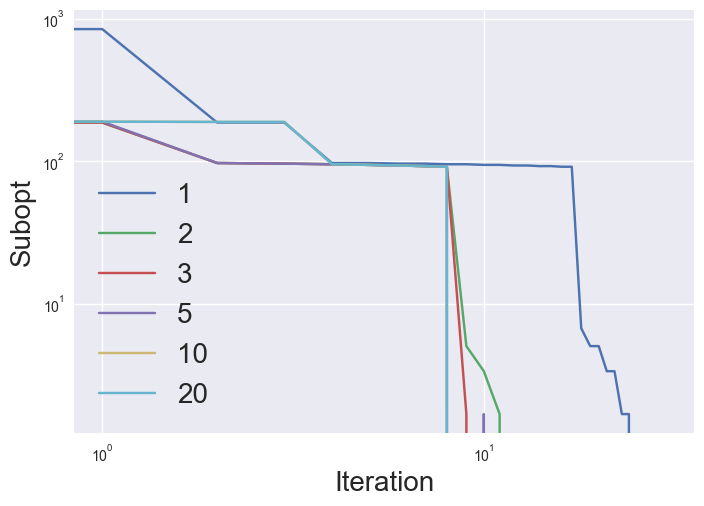

In [59]:
plot_log_lines(to_plot, 
           m_values, 
           ["Iteration", "Subopt"], "figs", "MPI.pdf", show = True)

**Questions** 
- How does the value of $m$ affect convergence ?
- Which is the cost per iteration of Modified Policy Iteration ?
- Which is the cost per iteration of Policy Iteration implemented with Option 2 in the slides ?

***Answers***

m determines how many times the Bellman operator is applied before the policy is updated again. Overall, the higher m is, the faster it converges, though it should be noted that this only counts "outer" iterations. Higher m means iterations themselves are more costly. m = 1 takes a significantly longer time to converge compared to just m = 2, and m > 10 seems to converge at similar iterations. 

For Modified Policy Iteration, each outer iteration consists of policy evalutation (applying the Bellman operator m times) and then policy improvement (greedy step). Each Bellman update costs $\mathcal{O}(|S|^2 |A|)$ from slide 52 in lecture 1 (since a Bellman update is the same as a value iteration, and the cost of value iteration is given), thus using the modified policy iteration, evaluation costs $\mathcal{O}(m |S|^2 |A|)$. The greedy step (policy improvement) costs $\mathcal{O}(|S|^2 |A|)$ (for each action in each state, compute the sum of all states --> S*S*A). Adding gives $\mathcal{O}(m |S|^2 |A| + |S|^2 |A|) = \mathcal{O}((m + 1) |S|^2 |A|) = \mathcal{O}(m|S|^2 |A|)$ as m gets large, the + 1 becomes irrelavent.

The cost per iteration of Policy Iteration implemented with Option 2 (closed-form solution) is $\mathcal{O}(|S|^3 + |S|^2 |A|)$ according to slides 40 and 52 in lecture 1. For environments with many states this can be expensive, and it will be more expensive than the Modified Policy Iteration as long as m|A|<|S|.



# Ex 4: Q-Learning [20 pts.]

Now, we are ready to tackle the problem in the model free setting. For technical reasons, we focus on the finite horizon setting in this part and we compare two exploration strategies.
1. **$\varepsilon$-greedy** (Watkins, Christopher John Cornish Hellaby. “Learning from Delayed Rewards.” PhD Thesis, King’s College, Cambridge United Kingdom, 1989.)
  - Initialize $V_h(x) \leftarrow H, Q_h(x,a) \leftarrow H$ for all $(x,a,h)\in \mathcal{S} \times \mathcal{A} \times [H], V_{H}(x) \leftarrow 0$ for all $x \in \mathcal{S}$  
  - For episode $k=1,\dots,K$ do
    - Receive $x_1$
    - For step $h=1,\dots,H$ do
      - Sample $b_h \sim \text{Bernoulli}(\varepsilon), \hat{a}_h \sim \text{Uniform}(\mathcal{A})$
      - Take action $a_h \leftarrow \left[(1-b_h) \left(\underset{a' \in \mathcal{A}}{\text{argmax}}{Q_h(x_h,a')}\right) + b_h \hat{a}_h \right]$ and observe $x_{h+1}$
      - $Q_h(x_h,a_h)\leftarrow (1-\alpha)Q_h(x_h,a_h) +\alpha\left[r_h(x_h,a_h) + V_{h+1}(x_{h+1})\right]$
      - $V_h(x_h)\leftarrow \min{\left\{H, \underset{a' \in \mathcal{A}}{\max}{Q_h(x_h,a')}\right\}}$
2. **UCB bonuses** (Jin, Chi, Zeyuan Allen-Zhu, Sebastien Bubeck, and Michael I Jordan. “Is Q-Learning Provably Efficient?” In Advances in Neural Information Processing Systems, Vol. 31. Curran Associates, Inc., 2018. https://proceedings.neurips.cc/paper/2018/hash/d3b1fb02964aa64e257f9f26a31f72cf-Abstract.html.)
  - Initialize $V_h(x) \leftarrow H, Q_h(x,a) \leftarrow H$ and $N_h(x,a) \leftarrow 0$ for all $(x,a,h)\in \mathcal{S} \times \mathcal{A} \times [H], V_{H}(x) \leftarrow 0$ for all $x \in \mathcal{S}$  
  - For episode $k=1,\dots,K$ do
    - Receive $x_1$
    - For step $h=1,\dots,H$ do
      - Take action $a_h \leftarrow \underset{a' \in \mathcal{A}}{\text{argmax}}{Q_h(x_h,a')}$ and observe $x_{h+1}$
      - $t=N_h(x_h,a_h)\leftarrow N_h(x_h,a_h) + 1, \alpha_t = \frac{H+1}{H+t}$ and $b_t \leftarrow c\sqrt{\frac{H^3}{t}}$
      - $Q_h(x_h,a_h)\leftarrow (1-\alpha_t)Q_h(x_h,a_h) +\alpha_t\left[r_h(x_h,a_h) + V_{h+1}(x_{h+1}) + b_t\right]$
      - $V_h(x_h)\leftarrow \min{\left\{H, \underset{a' \in \mathcal{A}}{\max}{Q_h(x_h,a')}\right\}}$

For other technical reason, we also need to rescale the reward between 0 and 1, as done in the following

In [60]:
reward_mode = 0
size = 10
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

### Q learning with epsilon greedy 

In this subsection, we implement $Q$ Learning with the simplest possible exploration strategy: $\epsilon$-greedy.

In [61]:
def argmax_with_random_tie_breaking(b):
    return np.random.choice(np.where(b == b.max())[0])

In [62]:
def q_learning_epsilon_greedy(K: int = 100000, H: int = 20, epsilon: float = 0.1, alpha: float = 0.1) -> List[float]:
    """
    Function implementing the epsilon-greedy Q-learning algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param epsilon: Algorithm hyperparameter, exploration probability, float in [0, 1]
    :param alpha: Algorithm hyperparameter, Q update weight, float in [0, 1]

    :return: reward after each step, list of K * H floats
    """
    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    V[H, :] = 0

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):  # Step loop
            explore = np.random.binomial(2, p=epsilon)
            if explore:
                # Exploration: With probability epsilon take a random action
                a = np.random.choice(gridworld.n_actions)
            else:
                # Exploitation: With probability 1 - epsilon take one of the optimal actions for the current state
                a = argmax_with_random_tie_breaking(Q[h, state, :])

            # Get reward for action
            rewards.append(gridworld.r[state, a])

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])

            # Update Q according to the algorithm
            Q[h, state, a] = (1 - alpha) * Q[h, state, a] + alpha * (gridworld.r[state, a] + V[h + 1, new_state]) # ???

            # Update V as the Q-value of the optimal actions for the current state
            V[h, state] = np.min([np.max(Q[h, state, :]), H])

            state = new_state
    return rewards

In [63]:
reward_eps_greedy = q_learning_epsilon_greedy()  # You can play around with the arguments if you like
cumulative_reward_eps_greedy = np.cumsum(reward_eps_greedy)

### Q-Learning with bonuses

In this subsection, you are asked to implement an optimistic version of  Q Learning suggested in (Jin et al., 2018)

In [64]:
def q_learning_ucb_bonuses(K: int = 100000, H: int = 20, c: float = 0.0001) -> List[float]:
    """
    Function implementing the Q-learning with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param c: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    V[H, :] = 0
    N = np.ones((H, gridworld.n_states, gridworld.n_actions))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):  # Step loop
            # Take one of the optimal actions for the current state
            a = argmax_with_random_tie_breaking(Q[h, state, :])
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])

            # Calculate the UCB bonus
            bonus = c * np.sqrt(H ** 3 / N[h, state, a])

            # Calculate the adaptive alpha according to the algorithm
            alpha = (H + 1) / (H + N[h, state, a])

            # Update Q according to the algorithm
            Q[h, state, a] = (1 - alpha) * Q[h, state, a] + alpha * (gridworld.r[state, a] + V[h + 1, new_state] + bonus) # ???

            # Update V as the Q-value of the optimal actions for the current state
            V[h, state] = np.max(Q[h, state, :])
            V[h, state] = np.clip(V[h, state], 0, H)

            state = new_state

    return rewards

In [65]:
reward_UCB = q_learning_ucb_bonuses()  # You can play around with the arguments if you like
cumulative_reward_UCB = np.cumsum(reward_UCB)

### Comparison of exploration strategies

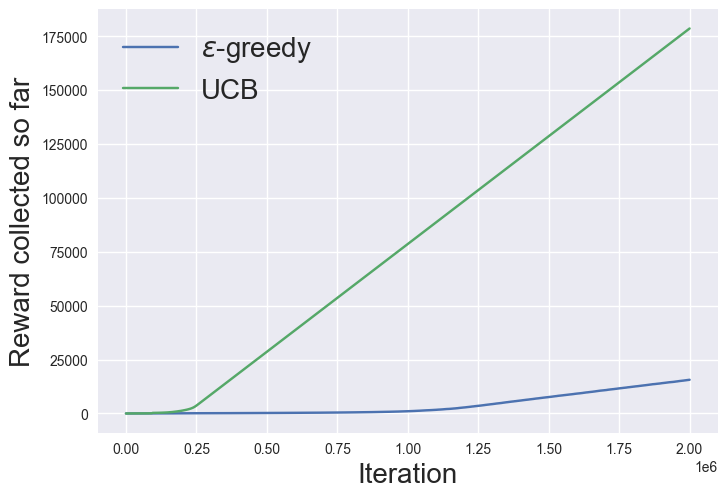

In [66]:
plot_lines(
    [cumulative_reward_eps_greedy, cumulative_reward_UCB],
    [r"$\epsilon$-greedy", "UCB"],
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=True
)

**Question:** You are given an environment with $N$ states linked in a chain, i.e. from every state except the two endpoints there are two possible actions going right or go back to the first state in the chain. For the endpoints the second action is to stay in the same state. The reward is only 1 if you are in the rightmost state and stay there, otherwise 0. What is the probability that the $\varepsilon$-greedy algorithm will have a positive reward after $H$ steps in the first episode, if the chosen initial state is the leftmost state in the chain? For simplicity you can consider the case $H=N$.

In order to have a positive reward after $H$ steps in the first episode, the policy must go right until the right-most state, and then stay there. Initially, all $Q_h(s,a)$ values are equal, thus the algorithm selects a greedy action With probability $1 - \varepsilon$, or the algorithm selects a random action with probability $\varepsilon$. Since all Q-values are tied in the first episode, greedy selection also breaks ties randomly. Therefore, at every state $\mathbb{P}(\text{choose right}) = \frac{1}{2}$ independently of $\varepsilon$. To receive a reward, the agent must choose the correct action N times in a row.
$$
\mathbb{P}(\text{positive reward in first episode})
=
\left(\frac{1}{2}\right)^N
=
2^{-N}.
$$

The probability that the $\varepsilon$-greedy algorithm obtains a positive reward in the first episode (with H = N) is $2^{-N}$. That is extremely small, and explains why the algorithm struggles in the chain environment. 

**Question:** Does the empirical result match the theoretical result described in (Jin et al. 2018) ? Try to answer this question after reading their Appendix A and looking at their Table 1 for the algorithm they call UCB-H.

In the [paper](https://arxiv.org/pdf/1807.03765), regret is used to quantify and compare the heuristics of the different RL methods. Regret is the cumulative difference between the agent's reward, and an optimal agent's reward. From Table 1, UCB-H achieves a regret of $\tilde{\mathcal{O}}(\sqrt{H^4 SAT})$, implying cumulative reward grows toward the optimum proportional to $\sqrt{T}$. This is reflected empirically: the UCB agent accumulates reward steadily and converges toward optimal behavior.

In contrast, Appendix A shows that $\varepsilon$-greedy with zero initialization can require up to $K \geq \Omega(A^{H/2})$ episodes before observing any non-zero reward, very similar to the situation in the question above. When the reward is very sparse, the agent must happen to stumble upon the correct sequence of states/actions (s*, a*, ... , s*, a*) by chance, or else all Q-values remain at zero and no learning occurs. This can be seen clearly in the graph, as the $\varepsilon$-greedy stays around zero for almost one million iterations. This exponential dependence on H explains the empirically slower reward accumulation of $\varepsilon$-greedy. This problem is eliminated with UCB-H because the bonus incentivizes the agent to systematically try new things, in contrast to just trying things randomly. UCB-H is seen to begin earning rewards within 250k iterations.

## Monte Carlo (MC) and Time Differences (TD) ( * Question ) [20 points]

Disclaimer: The TA can not help you on this part of the notebook.

In [67]:
def generate_episode(policy: List, H: int, initial_state: int):
    """
    Generate an episode using the given policy.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param H: Maximum number of steps in the episode.
    :param initial_state: Starting state.

    :return: A list of (state, action, reward) tuples.
    """
    episode = []
    state = initial_state
    for _ in range(H):
        action = policy[state]
        reward = gridworld.r[state, action]
        next_state = np.random.choice(gridworld.n_states, p=gridworld.T[action][state])
        episode.append((state, action, reward))
        state = next_state
    return episode

def mc_policy_evaluation_with_linear_approx(
    policy: List[np.ndarray], 
    phi: np.ndarray,
    K: int = 1000, 
    H: int = 20, 
    gamma: float = 0.99, 
    alpha: float = 0.01
) -> np.ndarray:
    """
    Monte Carlo policy evaluation with linear function approximation.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param K: Number of episodes.
    :param H: Maximum number of steps per episode.
    :param gamma: Discount factor.
    :param alpha: Learning rate for gradient descent.

    :return: The learned weight vector theta.
    """
    # Feature matrix: Each state is represented by a one-hot vector
    n_states = gridworld.n_states

    # Initialize weight vector theta
    theta = np.zeros(n_states)

    for _ in range(K):  # Episode loop
        episode = generate_episode(policy, H, initial_state=99)  # Generate episode
        G = 0  # Return

        # Backward pass through the episode
        for t in range(len(episode) - 1, -1, -1):
            state, _, reward = episode[t]
            G = gamma * G + reward  # Discounted return

            # Update theta using gradient descent
            phi_s = phi[state]  # Feature vector for the current state
            V_hat = np.dot(theta, phi_s)  # Current value estimate
            theta -= alpha * phi_s * (V_hat - G) # ???  # Gradient descent update

    return theta


In [68]:

import numpy as np
def td_policy_evaluation_with_linear_approx(
    policy: List[np.ndarray], 
    phi: np.ndarray,
    K: int = 1000, 
    H: int = 20, 
    gamma: float = 0.99, 
    alpha: float = 0.01
) -> np.ndarray:
    """
    Temporal Difference (TD) policy evaluation with linear function approximation.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param K: Number of episodes.
    :param H: Maximum number of steps per episode.
    :param gamma: Discount factor.
    :param alpha: Learning rate for gradient descent.

    :return: The learned weight vector theta.
    """
    # Feature matrix: Each state is represented by a one-hot vector
    n_states = gridworld.n_states

    # Initialize weight vector theta
    theta = np.zeros(n_states)

    for _ in range(K):  # Episode loop
        state = 99  # Initial state
        for _ in range(H):  # Step loop
            # Sample action from policy
            action = policy[state]
            reward = gridworld.r[state, action]
            next_state = np.random.choice(gridworld.n_states, p=gridworld.T[action][state])

            # Compute TD target and TD error
            phi_s = phi[state]  # Feature vector for current state
            phi_s_next = phi[next_state]  # Feature vector for next state
            V_s = np.dot(theta, phi_s)  # Current value estimate
            V_s_next = np.dot(theta, phi_s_next)  # Next value estimate
            td_target = reward + gamma * V_s_next # ???  # TD target
            td_error = V_s - td_target # ???  # TD error

            # Update theta using gradient descent
            theta -= alpha * td_error * phi_s # ???

            # Move to the next state
            state = next_state

    return theta

**Case 1:**

In [69]:
_, pi=policy_iteration(gridworld)

phi = np.eye(gridworld.n_states)  # Feature matrix (one-hot encoding)
# Run Monte Carlo policy evaluation with linear function approximation
theta_MC = mc_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)
theta_TD = td_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)

print(np.linalg.norm(theta_MC  - theta_TD))

8.919948611419325e-07


**Case 2:**

In [70]:
_, pi=policy_iteration(gridworld)

phi = np.eye(gridworld.n_states)  # Feature matrix (one-hot encoding)
phi[:50,:]*=0

# Run Monte Carlo policy evaluation with linear function approximation
theta_MC = mc_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)
theta_TD = td_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)

print(np.linalg.norm(theta_MC  - theta_TD))

190.43020836185028


**Questions:** 
- Does the solution coincide ( up to numerical error ) in Case 1?
- Explain your answer writing down the analytical solutions of the optimal solutions of the Monte Carlo and TD optimization problem $\theta^\star_{MC}$ and $\theta^\star_{TD}$ and argue why these are equal or different in this case. To give this answer you can assume that $\rho$ is positive everywhere.

**Answers**


Yes, the solution coincides. The difference between the solution using Monte Carlo and TD is 8.919948611419325e-07, which is extremely small, signifying they have converged to the same point (with some numerical error). 

In Slide 32 from lecture 2 $\varepsilon_{approx}$ is defined as $\text{min}_{\theta} ||\Phi \theta - V^\pi ||_\rho$. If $\varepsilon_{approx} = 0$ then the MC and TD solutions converge to the same point, otherwise, they converge to different points. In plain english, this roughly means that if there exists a theta that makes $\Phi \theta = V^\pi$ then the two solutions converge. For case 1 phi is initialized as the identity matrix (np.eye). In this case, every state has its own independent parameter, and thus the approximation can be exact.

$\theta^*_{MC}$ from Slide 32, the optimality condition $\nabla_\theta L(\theta^*_{MC})$ = 0 implies that:

$$\theta^*_{MC} = (\Phi^T \text{diag}(\rho)\Phi)^{-1}\Phi^T \text{diag}(\rho)V^\pi$$

With $\Phi$ = I (identity matrix) this simplifies to:

$$\theta^*_{MC} = V^\pi$$

$\theta^*_{TD}$ from Slide 34:

$$\theta^*_{TD} = (\Phi^T\text{diag}(\rho)\Phi)^{-1}\Phi^T\text{diag}(\rho)T^\pi\Phi\theta^*_{TD}$$

With $\Phi$ = I (identity matrix) this simplifies to:

$$\theta^*_{TD} = T^\pi \theta^*_{TD}$$

This is the fixed point of the Bellman operator, and which means $\theta^*_{TD}$ converges to $V^\pi$.
$$\theta^*_{TD} = V^\pi$$

Therefore $\Phi\theta^*_{MC} = \Phi\theta^*_{TD} = V^\pi$ (the solutions coincide).

**Questions:** 
- Does the solution coincide ( up to numerical error ) in Case 2?
- Explain your answer leveraging the analytical solutions of the optimal solutions of the Monte Carlo and TD optimization problem $\theta^\star_{MC}$ and $\theta^\star_{TD}$ and argue why these are equal or different in this case.
- Let $\Phi$ be the feature matrix. Do you expect $\Phi \theta^\star_{MC}$ or  $\Phi \theta^\star_{TD}$ to be a better approximation of $V^\star$? Point to a formal result in the lecture slides when giving your answer.

The solution does NOT coincide. The difference between the MC and TD solutions is 190.43020836185028, a relatively large non-zero number. For case 2, phi is initialized as the identity matrix with the first 50 rows zeroed. 

Using the same definition for $\varepsilon_{approx}$, in this case because the first 50 rows of $\Phi$ are zeroed, states 0-49 all have (from slide 10) $\phi(s) = 0$, so $V_\theta(s) = \phi(s)^T\theta = 0$ for those states regardless of $\theta$. Since $V^\pi$ is not zero for those states, no $\theta$ can make $\Phi\theta = V^\pi$ exactly. Again from slide 32, when $\varepsilon_{approx} > 0$, MC and TD converge to different points.

$\theta^*_{MC}$ from Slide 32:
$$\theta^*_{MC} = (\Phi^T \text{diag}(\rho)\Phi)^{-1}\Phi^T \text{diag}(\rho)V^\pi$$
This is the projection of $V^\pi$ onto the column space of $\Phi$. This only involves $\Phi$ and $V^\pi$, it minimises the weighted mean square error directly with no dependence on transitions.

$\theta^*_{TD}$ from Slide 34:
$$\theta^*_{TD} = (\Phi^T\text{diag}(\rho)\Phi)^{-1}\Phi^T\text{diag}(\rho)T^\pi\Phi\theta^*_{TD}$$
This is the fixed point of the Bellman equation. Unlike $\theta^*_{MC}$, it explicitly depends on the transition matrix $T^\pi$. This matters because states 0-49 (zero rows) can transition to or from states 50-99 (nonzero rows) at any time, thus TD's updates for states 50-99 may be corrupted by the incorrect 0 estimates of states 0-49. MC avoids this because it uses the real return $G$ from full episodes and does not build off wrong estimates. 

$\Phi\theta^*_{MC}$ is the better approximation of $V^\pi$. From Slide 33:
$$\|V_{\theta^*_{TD}} - V^\pi\|_\rho \leq \frac{1}{\sqrt{1-\gamma^2}}\|\Phi\theta^*_{MC} - V^\pi\|_\rho$$

Slide 33 in lecture 2 clearly states "the minimum possible approximation error is achieved by the MC method". TD has an additional error multiplier of $\frac{1}{\sqrt{1-\gamma^2}}$ on top of the minimum error that MC already achieves.